# En este Notebook se ajustan los datos para entrenar un modelo con machine learning que permita la deteccion de fibrosis hepatica con base en los estudios clinicos.

## importe librerias

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib
import os
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier


## Cargue de la  data

In [2]:
# cargue de archivos
data = 'data/csv/data.csv'
dx='data/csv/DX.csv'
laboratorios='data/csv/Laboratorios.csv'
motivo_consulta='data/csv/motivoconsulta.csv'
personales='data/csv/Personales.csv'

In [3]:
data_df = pd.read_csv(data)
dx_df = pd.read_csv(dx)
laboratorios_df = pd.read_csv(laboratorios)
motivo_consulta_df = pd.read_csv(motivo_consulta)
personales_df = pd.read_csv(personales)

## Preparacion de la informacion

In [4]:
laboratorios_df.head(3)

,RESULTADO_1,FECHA_EXAMEN,PRUEBA,Codigo,FIBROSIS,NUMPACIENTE,ESTUDIO,RESULTADO_2
0,0.22,2017-07-30 08:53:38,BILIRRUBINA DIRECTA,0-1,F0,1,BILIRRUBINAS,0.22
1,0.78,2017-07-30 08:53:38,BILIRRUBINA INDIRECTA,0-1,F0,1,BILIRRUBINAS,0.78
2,1,2017-07-30 08:53:38,BILIRRUBINA TOTAL,0-1,F0,1,BILIRRUBINAS,1


In [5]:
#Transformación de datos de laboratorios
df_pivot = laboratorios_df.pivot(
    index=['NUMPACIENTE', 'FECHA_EXAMEN'], 
    columns='PRUEBA', 
    values='RESULTADO_1',
)

# limpiar nombres de columnas
df_pivot = df_pivot.reset_index()
df_pivot.columns.name = None

df_pivot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3124 entries, 0 to 3123
Data columns (total 12 columns):
 #   Column                                                                      Non-Null Count  Dtype 
---  ------                                                                      --------------  ----- 
 0   NUMPACIENTE                                                                 3124 non-null   int64 
 1   FECHA_EXAMEN                                                                3124 non-null   object
 2   BILIRRUBINA DIRECTA                                                         1171 non-null   object
 3   BILIRRUBINA INDIRECTA                                                       1171 non-null   object
 4   BILIRRUBINA TOTAL                                                           1171 non-null   object
 5   DESHIDROGENASA LACTICA (LDH)                                                92 non-null     object
 6   FOSFATASA ALCALINA                                      

*Hallazgos*
* No se tiene uniformidad en los examenes realizados a los pacientes
* Se tiene alto numero de datos vacios
* Un paciente puede tener diferentes examenes en un dia

*Estrategia implementada*

*   Se agrupan los datos clinicos por Paciente y Día. Si hubo múltiples tomas en un día, se calcula el promedio.
* Se asume que el valor de un examen (ej. Plaquetas) se mantiene constante desde la última medición hasta que se haga una nueva. Esto refleja mejor la realidad clínica que rellenar con ceros o promedios globales.
* Se calcula la diferencia respecto a la medición anterior. Se espera que incluya mas informacion al modelo para que realice una mejor prediccion.

In [6]:
df = df_pivot
# Estandarizacion Fecha
df['FECHA_EXAMEN'] = pd.to_datetime(df['FECHA_EXAMEN'])
df['FECHA_DIA'] = df['FECHA_EXAMEN'].dt.normalize()

# LIMPIEZA DE COLUMNAS NUMÉRICAS
cols_excluir = ['NUMPACIENTE', 'FECHA_EXAMEN', 'FECHA_DIA', 'FIBROSIS']
cols_pruebas = [col for col in df.columns if col not in cols_excluir]

print(f"Detectadas {len(cols_pruebas)} columnas de pruebas.")

# Forzamos la conversión a numérico (reemplazando comas por puntos si existen)
for col in cols_pruebas:
    # Si es tipo objeto (string), reemplazar coma por punto
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.replace(',', '.')
    # Convertir a número, los errores se vuelven NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Agrupar por Paciente y Día
df_grouped = df.groupby(['NUMPACIENTE', 'FECHA_DIA'])[cols_pruebas].mean().reset_index()

# Imputación (Forward Fill) - Rellenar valores vacios con el último valor del paciente
df_clean = df_grouped.copy()
# Aplicamos ffill solo a las columnas de pruebas, respetando el grupo
df_clean[cols_pruebas] = df_grouped.groupby('NUMPACIENTE')[cols_pruebas].ffill()

df_clean = df_clean.fillna(0)

# Union con variable target
laboratorios_df[['NUMPACIENTE', 'FIBROSIS']].drop_duplicates(subset=['NUMPACIENTE'])
target_map = laboratorios_df[['NUMPACIENTE', 'FIBROSIS']].drop_duplicates(subset=['NUMPACIENTE'])
df_clean = pd.merge(df_clean, target_map, on='NUMPACIENTE', how='inner')

df_clean.info()


Detectadas 10 columnas de pruebas.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1592 entries, 0 to 1591
Data columns (total 13 columns):
 #   Column                                                                      Non-Null Count  Dtype         
---  ------                                                                      --------------  -----         
 0   NUMPACIENTE                                                                 1592 non-null   int64         
 1   FECHA_DIA                                                                   1592 non-null   datetime64[ns]
 2   BILIRRUBINA DIRECTA                                                         1592 non-null   float64       
 3   BILIRRUBINA INDIRECTA                                                       1592 non-null   float64       
 4   BILIRRUBINA TOTAL                                                           1592 non-null   float64       
 5   DESHIDROGENASA LACTICA (LDH)                                         


El archivo resultante no tiene valores vacíos y se dejo una fila única por fecha de examen.

# Entrenamiento del modelo para deteccion temprana del estadio de fibrosis



In [11]:
# Preparar conjunto de datos
X = df_clean.drop(['NUMPACIENTE', 'FECHA_DIA', 'FIBROSIS'], axis=1)
y = df_clean['FIBROSIS']

# Label encoder para la variable target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Dividir en Entrenamiento (80%) y Prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Estandarización de los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ENTRENAMIENTO MODELOS - SMV - RANDOM FOREST Y DECISION TREE

# Diccionario con los modelos configurados
models = {
    "SVM (Kernel Radial)": SVC(kernel='rbf', random_state=42), 
    "Árbol de Decisión": DecisionTreeClassifier(max_depth=10, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Bucle para entrenar y evaluar cada uno
for name, model in models.items():
    print(f"\n--- Entrenando: {name} ---")
    
    # Entrenar
    model.fit(X_train_scaled, y_train)
    # Predecir
    y_pred = model.predict(X_test_scaled)
    # Evaluar
    acc = accuracy_score(y_test, y_pred)
    joblib.dump(model, f'{name.replace(" ", "_").lower()}_model.joblib')
    print(f"Exactitud (Accuracy): {acc:.2%}")
    print("Reporte de Clasificación:")
    print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))


--- Entrenando: SVM (Kernel Radial) ---
Exactitud (Accuracy): 69.59%
Reporte de Clasificación:
              precision    recall  f1-score   support

          F0       1.00      0.89      0.94        19
          F1       0.51      0.55      0.53        71
          F2       0.83      0.58      0.68        33
          F3       0.80      0.68      0.73       106
          F4       0.66      0.83      0.74        90

    accuracy                           0.70       319
   macro avg       0.76      0.71      0.73       319
weighted avg       0.71      0.70      0.70       319


--- Entrenando: Árbol de Decisión ---
Exactitud (Accuracy): 84.01%
Reporte de Clasificación:
              precision    recall  f1-score   support

          F0       0.81      0.89      0.85        19
          F1       0.72      0.93      0.81        71
          F2       0.67      0.61      0.63        33
          F3       0.95      0.90      0.92       106
          F4       0.92      0.78      0.84       

El modelo que mejor performance obtuvo fue el random forest con una presicion de 94.8% y la siguiente matriz de confusion

In [ ]:
# 1. Crear un diccionario con todo lo necesario
# Asumiendo que tus variables se llaman: model, scaler, le (LabelEncoder) y X (para sacar los nombres)
artifacts = {
    'model': model,              # El modelo entrenado (Random Forest)
    'scaler': scaler,            # El escalador ajustado (media y desviación estándar)
    'encoder': le,               # El traductor de F0..F4
    'features': X.columns.tolist() # La lista exacta de columnas en orden
}

# 2. Guardar en un solo archivo
nombre_archivo = 'modelo_fibrosis_v1.joblib'
joblib.dump(artifacts, nombre_archivo)

print(f"✅ Todo guardado exitosamente en: {nombre_archivo}")
print("Contenido del paquete:", artifacts.keys())

In [ ]:

    # Predecir
    y_pred = model.predict(X_test_scaled)
    # Evaluar
    acc = accuracy_score(y_test, y_pred)
    print(f"Exactitud (Accuracy): {acc:.2%}")
    print("Reporte de Clasificación:")
    print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

todo


--- Top 5 Variables más Importantes ---
1. GAMMA GLUTAMIL TRANSFERASA (GGT) (0.1653)
2. DESHIDROGENASA LACTICA (LDH) (0.1464)
3. PLAQUETAS (0.1151)
4. FOSFATASA ALCALINA (0.1087)
5. BILIRRUBINA DIRECTA (0.0850)


C:\Users\pinka\AppData\Local\Temp\ipykernel_19752\2857697883.py:20: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


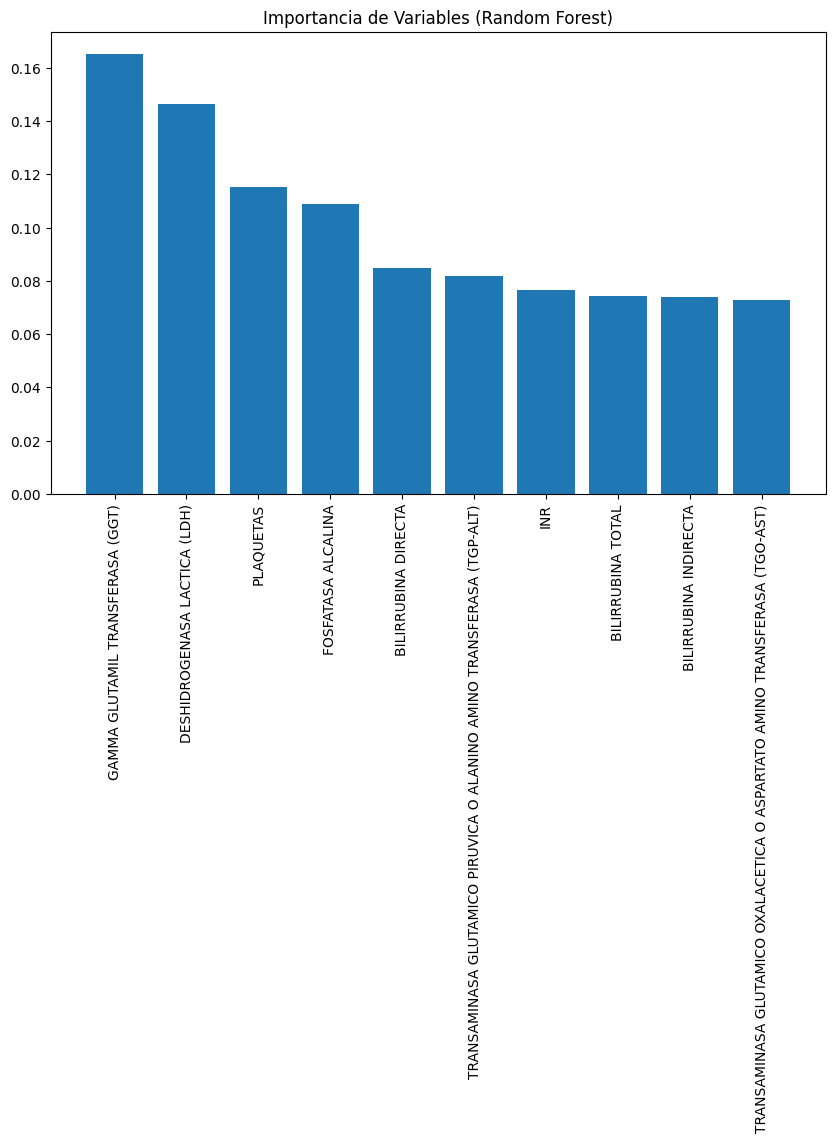

NameError: name 'df_ml' is not defined

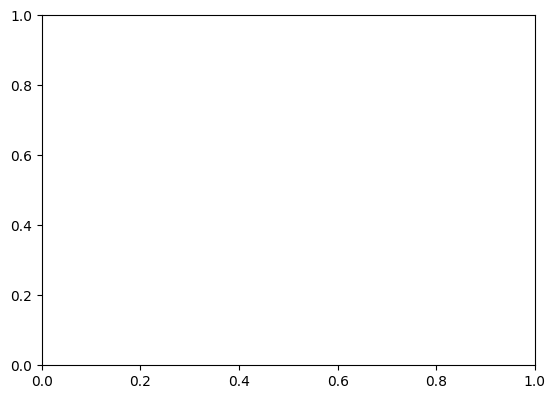

In [13]:
# --- 3. ANÁLISIS DE IMPORTANCIA (Feature Importance) ---

# Obtener la importancia de cada variable según el modelo
importances = model.feature_importances_
indices = np.argsort(importances)[::-1] # Ordenar de mayor a menor

print("\n--- Top 5 Variables más Importantes ---")
top_features = []
for i in range(5):
    feature_name = X.columns[indices[i]]
    importance_val = importances[indices[i]]
    top_features.append(feature_name)
    print(f"{i+1}. {feature_name} ({importance_val:.4f})")

# Graficar Importancia
plt.figure(figsize=(10, 6))
plt.title("Importancia de Variables (Random Forest)")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.tight_layout()
plt.show()

# --- 4. ANÁLISIS CUALITATIVO (BOXPLOTS) ---
# Visualizar cómo cambian las variables más importantes según el grado de Fibrosis

# Seleccionar las 4 variables más importantes para graficar
features_to_plot = top_features[:4]

plt.figure(figsize=(14, 10))
for i, feature in enumerate(features_to_plot):
    plt.subplot(2, 2, i+1)
    # Usamos seaborn para crear boxplots divididos por la clase de Fibrosis
    sns.boxplot(x='FIBROSIS', y=feature, data=df_ml, order=np.sort(df_ml['FIBROSIS'].unique()))
    plt.title(f'Distribución de {feature} por Grado de Fibrosis')
    plt.xlabel('Grado de Fibrosis')
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

print("Análisis completado. Observa los gráficos para interpretar la relación clínica.")

In [ ]:
import shap

# Crear un explicador basado en árboles
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

# Gráfico resumen (Beeswarm plot)
# Muestra cómo valores altos/bajos de cada feature impactan positiva o negativamente a la predicción
shap.summary_plot(shap_values, X, plot_type="bar")

## Convertir cada hoja a CSV

Esto facilitará el trabajo futuro y mejorará el rendimiento del análisis.

In [ ]:
import os

# Crear carpeta para los CSV si no existe
csv_folder = "C:\\Users\\wired\\Downloads\\Proyecto_Final_Applied_Data_Science\\Notebooks\\data\\csv"
os.makedirs(csv_folder, exist_ok=True)

# Convertir cada hoja a CSV
for sheet_name in excel_file.sheet_names:
    # Leer la hoja
    df = pd.read_excel(excel_file, sheet_name=sheet_name)
    
    # Crear nombre del archivo CSV (reemplazar caracteres especiales)
    csv_filename = sheet_name.replace(" ", "_").replace("/", "-")
    csv_path = os.path.join(csv_folder, f"{csv_filename}.csv")
    
    # Guardar como CSV
    df.to_csv(csv_path, index=False, encoding='utf-8-sig')


### Analisis Exploratorio de datos por hoja

### 3. Hoja: DX

In [ ]:
# Cargar hoja 'DX'
df_dx = pd.read_csv(f"{csv_folder}/DX.csv")
print(f"Dimensiones: {df_dx.shape}")
print(f"Columnas: {list(df_dx.columns)}")
df_dx.head()

### Analisis Univariado y Bivariado

In [ ]:
eventos_unicos = df_dx["EVENTO"].nunique()
pacientes_unicos = df_dx["NUMPACIENTE"].nunique()
total_registros = len(df_dx)

print(f"Total de registros: {total_registros}")
print(f"Total de eventos únicos: {eventos_unicos}")
print(f"Total de pacientes únicos: {pacientes_unicos}")
print(f"Promedio de eventos por paciente: {eventos_unicos / pacientes_unicos:.2f}")


In [ ]:
df_dx.groupby("NUMPACIENTE")["EVENTO"].nunique().describe()


In [ ]:
df_dx["FIBROSIS"].value_counts()

In [ ]:
fibrosis_por_paciente = df_dx.groupby("NUMPACIENTE")["FIBROSIS"].nunique()
print("Pacientes con más de un estadio de fibrosis:", (fibrosis_por_paciente > 1).sum())


In [ ]:
# Contar el número de eventos por paciente
eventos_por_paciente = (
    df_dx.groupby("NUMPACIENTE")["EVENTO"]
    .count()
    .reset_index(name="num_eventos")
    .sort_values(by="num_eventos", ascending=False)
)

# Obtener el Top 3 de pacientes con más eventos
top3_pacientes = eventos_por_paciente.head(3)

# Cruzar con la información de fibrosis
top3_fibrosis = (
    df_dx.merge(top3_pacientes, on="NUMPACIENTE")[["NUMPACIENTE", "FIBROSIS", "num_eventos"]]
    .drop_duplicates(subset=["NUMPACIENTE"])
    .sort_values(by="num_eventos", ascending=False)
)

print("Top 3 pacientes con mayor número de eventos y su estado de fibrosis:\n")
print(top3_fibrosis.to_string(index=False))


Esta hoja no evidencia una evolucion de la estadia de la enefermedad en los pacientes a traves del tiempo.

In [ ]:
# Obtener el diagnóstico más frecuente por cada estadio
diagnostico_top = (
    df_dx.groupby("FIBROSIS")["NOMBRE_DIAGNOSTICO"]
    .agg(lambda x: x.value_counts().idxmax())
)

print("Diagnóstico más frecuente por estadio de fibrosis:\n")
for fibrosis, diag in diagnostico_top.items():
    print(f"{fibrosis}: {diag}")



En los estadios F0, F1 y F2 predomina el diagnóstico de *degeneración grasa del hígado*, lo que indica que en las fases tempranas la enfermedad se asocia principalmente con este tipo de alteración hepática. En cambio, en los estadios avanzados F3 y F4 el diagnóstico más frecuente corresponde a *otras cirrosis del hígado*, reflejando la progresión natural hacia un daño hepático crónico y estructural.


In [ ]:
principal = df_dx[df_dx["PRINCIPAL"]=="S"]
print(principal["FIBROSIS"].value_counts(normalize=True))


La mayor proporción de diagnósticos principales corresponde al estadio F1 (36%), lo que sugiere que muchos pacientes son identificados en fases tempranas o en seguimiento inicial de la fibrosis. Los estadios avanzados F3 y F4 representan cerca del 25% cada uno, reflejando casos más graves esperables en un hospital de referencia. En contraste, los estadios leves F0 y F2 son menos frecuentes (5.7% y 9.4%), coherente con su detección habitual en evaluaciones secundarias o de control.

### **Analisis Grafico**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contar pacientes únicos por estadio de fibrosis
pacientes_por_fibrosis = df_dx.groupby("FIBROSIS")["NUMPACIENTE"].nunique().reindex(["F0","F1","F2","F3","F4"])

plt.figure(figsize=(6,4))
sns.barplot(x=pacientes_por_fibrosis.index, y=pacientes_por_fibrosis.values, palette="viridis")
plt.title("Pacientes únicos por estadio de fibrosis")
plt.xlabel("Estadio de fibrosis")
plt.ylabel("Número de pacientes únicos")
plt.show()


### 5. Hoja: personales

In [ ]:
# Cargar hoja 'personales'
df_personales = pd.read_csv(f"{csv_folder}/personales.csv")
print(f"Dimensiones: {df_personales.shape}")
print(f"Columnas: {list(df_personales.columns)}")
df_personales.head()

### **Analisis Grafico**

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.countplot(x="SEXO_PAC", data=df_personales, palette="pastel")
plt.title("Distribución de pacientes por sexo")
plt.xlabel("Sexo")
plt.ylabel("Número de pacientes")
plt.show()


In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(x="FIBROSIS", y="EDAD_ACTUAL", data=df_personales, order=["F0","F1","F2","F3","F4"], palette="mako")
plt.title("Edad promedio por estadio de fibrosis")
plt.xlabel("Estadio de fibrosis")
plt.ylabel("Edad promedio")
plt.show()


La gráfica muestra que la edad promedio de los pacientes con fibrosis hepática se concentra alrededor de los 60 años en todos los estadios, con ligeras variaciones. Aunque no se observa una relación lineal clara entre edad y severidad, los estadios más avanzados (F3 y F4) también se presentan principalmente en adultos mayores, lo que es coherente con la progresión crónica de la enfermedad hepática a lo largo del tiempo.

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(x="FIBROSIS", hue="SEXO_PAC", data=df_personales, order=["F0","F1","F2","F3","F4"], palette="Set2")
plt.title("Distribución de fibrosis por sexo del paciente")
plt.xlabel("Estadio de fibrosis")
plt.ylabel("Número de pacientes")
plt.legend(title="Sexo")
plt.show()


La gráfica muestra la distribución del estadio de fibrosis según el sexo de los pacientes. Se observa que las mujeres presentan una mayor frecuencia en casi todos los estadios, especialmente en F1 y F3, mientras que los hombres son menos numerosos en cada categoría. Esto podría indicar una mayor detección o seguimiento en mujeres, o bien reflejar diferencias en la exposición a factores de riesgo o en la búsqueda de atención médica entre ambos sexos.


### **Analisis Conjunto de las hojas**

In [ ]:
# Unir df_personales y df_dx por la columna NUMPACIENTE
df_merged = pd.merge(df_dx, df_personales, on=["NUMPACIENTE", "FIBROSIS"], how="inner")


print(f"Dimensiones: {df_merged.shape}")
print(f"Columnas: {df_merged.columns.tolist()}")
print(f"Registros únicos de pacientes: {df_merged['NUMPACIENTE'].nunique()}")
print(f"Estadios de fibrosis presentes: {df_merged['FIBROSIS'].unique()}")


# Vista previa
df_merged.head()


In [ ]:
print(f"Total de registros combinados: {len(df_merged)}")
print(f"Pacientes únicos: {df_merged['NUMPACIENTE'].nunique()}")
print(f"Estadios de fibrosis: {df_merged['FIBROSIS'].unique().tolist()}\n")

In [ ]:
edad_fibrosis_sexo = df_merged.groupby(["FIBROSIS", "SEXO_PAC"])["EDAD_ACTUAL"].mean().round(1)
print("Edad promedio por estadio y sexo:")
print(edad_fibrosis_sexo)

In [ ]:
plt.figure(figsize=(7,5))
sns.barplot(data=df_merged, x="FIBROSIS", y="EDAD_ACTUAL", hue="SEXO_PAC", ci=None)
plt.title("Edad promedio por estadio de fibrosis y sexo")
plt.xlabel("Estadio de fibrosis")
plt.ylabel("Edad promedio")
plt.tight_layout()
plt.show()


In [ ]:
# Edad promedio por diagnóstico (Top 10 más frecuentes)
edad_diagnostico = (
    df_merged.groupby("NOMBRE_DIAGNOSTICO")["EDAD_ACTUAL"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

print("Edad promedio por diagnóstico (Top 10 más frecuentes):\n")
print(edad_diagnostico.to_string(index=False))


In [ ]:
edad_eventos = (
    df_merged.groupby("FIBROSIS")[["EDAD_ACTUAL", "EVENTO"]]
    .agg({"EDAD_ACTUAL": "mean", "EVENTO": "count"})
    .rename(columns={"EVENTO": "Total_eventos"})
)

plt.figure(figsize=(6,4))
sns.heatmap(edad_eventos, annot=True, cmap="YlOrRd", fmt=".1f")
plt.title("Relación entre edad promedio, número de eventos y estadio de fibrosis")
plt.ylabel("Estadio de fibrosis")
plt.tight_layout()
plt.show()


La gráfica muestra que la edad promedio de los pacientes se mantiene estable entre los distintos estadios de fibrosis (entre 60 y 66 años), por lo que la edad no parece ser un factor diferenciador claro. Sin embargo, los estadios F1, F3 y F4 concentran un mayor número de eventos clínicos, lo que sugiere que los pacientes con fibrosis leve o avanzada requieren más seguimiento o presentan una mayor actividad médica, mientras que los casos sin fibrosis (F0) muestran menos registros.